**Section:** A
**Date:** May 3, 2026
**Responsibilities:** We split the work evenly.

# CAP3321C Final Project: Miami-Dade Restaurant Inspections

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Q1. Cleaning

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5092, 8)


In [3]:
df.isna().sum()

zip_code 0
inspection_date 0
cuisine 9
score 25
dtype: int64

There are 25 missing scores. We dropped them.

In [4]:
df = df.dropna(subset=['score'])
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

5040


Dates are converted and duplicates are removed, leaving 5,040 inspections. (zip_code is still a number.)

In [5]:
tmp = df.copy()

## Q2. Fail rate by ZIP code

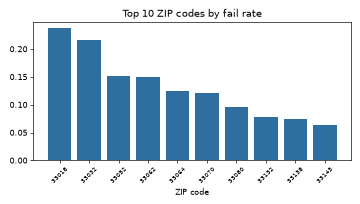

In [6]:
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

ZIP code 33018 has the highest fail rate at 23.7%, about twice the county-wide rate. The top ZIP codes are spread across the county rather than clustered, which suggests the cause is individual restaurants, not one neighborhood.

## Q3. Scores over time

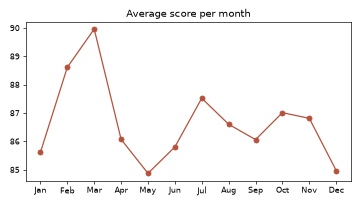

In [7]:
monthly = df.groupby(df['inspection_date'].dt.month)['score'].mean()
monthly.plot(marker='o')
plt.show()

Average scores peak in Mar (90.0) and are lowest in May (84.9). The swing is only a few points, so there is no strong seasonal effect, but the dip in May lines up with the summer months when kitchens run hotter and busier.

## Q4. Violations by cuisine

In [8]:
per = df.groupby('cuisine')['violations'].mean().sort_values(ascending=False)
per.head(4)

cuisine   violations_per_inspection
Mexican   3.73
Italian   3.33
Haitian   2.68
Peruvian  2.16

Mexican restaurants average 3.73 violations per inspection, nearly 1.7 times Peruvian. Cuisines with more cooking steps and more ingredient handling have more chances to be cited, so this is likely about process, not quality.